<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/Feature_Guided_GAN_with_Multi_Level_Perceptual_Supervision%22_Adds_Discriminator_%2B_Adversarial_Loss_to_your_original_feature_matching_baseline__.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import torch.nn.functional as F
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import os

IMG_SIZE = 64
LATENT_DIM = 128
BATCH_SIZE = 32
EPOCHS = 5  # You can increase
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
train_loader = DataLoader(
    datasets.CIFAR10(root="./data", train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)


100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


In [1]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, in_channels=3):
        super(Discriminator, self).__init__()
        def block(in_c, out_c, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, 64, normalize=False),  # 64x64 -> 32x32
            *block(64, 128),                           # 32x32 -> 16x16
            *block(128, 256),                          # 16x16 -> 8x8
            *block(256, 512),                          # 8x8 -> 4x4
            nn.Conv2d(512, 1, 4, stride=1),            # 4x4 -> 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)  # Flatten to [B]

# ✅ Test
if __name__ == "__main__":
    x = torch.randn(4, 3, 64, 64)
    D = Discriminator()
    out = D(x)
    print("Discriminator output shape:", out.shape)  # torch.Size([4])


Discriminator output shape: torch.Size([4])


In [2]:
# 📦 Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models, utils
import os

# ⚙️ Config
LATENT_DIM = 128
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS = 5
LAMBDA_FEAT = 10.0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 📚 CIFAR10 Dataset
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
loader = DataLoader(
    datasets.CIFAR10(root="./data", train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# 🧱 UpBlock
class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True)
        )

    def forward(self, x):
        return self.block(x)

# 🧠 Generator
class Generator(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 512 * 8 * 8)
        self.up1 = UpBlock(512, 256)
        self.up2 = UpBlock(256, 128)
        self.up3 = UpBlock(128, 64)
        self.out_conv = nn.Conv2d(64, 3, 3, padding=1)

    def forward(self, z):
        x = self.fc(z).view(-1, 512, 8, 8)
        f1 = self.up1(x)
        f2 = self.up2(f1)
        f3 = self.up3(f2)
        img = torch.tanh(self.out_conv(f3))
        return img, [f1, f2, f3]

# 🔍 VGG Feature Extractor (Frozen)
class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.layers = nn.ModuleList([
            nn.Sequential(*vgg[:16]),  # relu3_3 — 16x16
            nn.Sequential(*vgg[:9]),   # relu2_2 — 32x32
            nn.Sequential(*vgg[:4])    # relu1_2 — 64x64
        ])
        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        return [layer(x) for layer in self.layers]

# 🛡️ Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        def block(in_ch, out_ch, norm=True):
            layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(3, 64, norm=False),  # 64x64 -> 32x32
            *block(64, 128),            # 32x32 -> 16x16
            *block(128, 256),           # 16x16 -> 8x8
            *block(256, 512),           # 8x8 -> 4x4
            nn.Conv2d(512, 1, 4),       # 4x4 -> 1x1
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)

# 🚀 Initialize Models
G = Generator().to(device)
D = Discriminator().to(device)
Φ = VGGFeatureExtractor().to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=1e-4)
opt_D = torch.optim.Adam(D.parameters(), lr=1e-4)
bce = nn.BCELoss()

os.makedirs("gen_images", exist_ok=True)

# 🧪 Training Loop
for epoch in range(EPOCHS):
    for i, (real_img, _) in enumerate(loader):
        real_img = real_img.to(device)
        batch_size = real_img.size(0)
        valid = torch.ones(batch_size, device=device)
        fake = torch.zeros_like(valid)

        # --- Generator ---
        z = torch.randn(batch_size, LATENT_DIM).to(device)
        fake_img, fake_feats = G(z)
        real_feats = Φ(real_img)
        pred_fake = D(fake_img)

        loss_adv = bce(pred_fake, valid)
        loss_feat = sum(F.l1_loss(fg, fr.detach()) for fg, fr in zip(fake_feats, real_feats))
        loss_G = loss_adv + LAMBDA_FEAT * loss_feat

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # --- Discriminator ---
        pred_real = D(real_img)
        pred_fake_detached = D(fake_img.detach())
        loss_D = bce(pred_real, valid) + bce(pred_fake_detached, fake)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # --- Logging ---
        if i % 100 == 0:
            print(f"[Epoch {epoch+1}/{EPOCHS}] Batch {i} | G: {loss_G.item():.3f} | D: {loss_D.item():.3f}")
            utils.save_image(fake_img[:16], f"gen_images/fake_{epoch}_{i}.png", normalize=True, nrow=4)


100%|██████████| 170M/170M [00:03<00:00, 47.9MB/s]
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:06<00:00, 87.1MB/s]


[Epoch 1/5] Batch 0 | G: 20.716 | D: 1.403
[Epoch 1/5] Batch 100 | G: 26.692 | D: 0.027
[Epoch 1/5] Batch 200 | G: 24.475 | D: 0.055
[Epoch 1/5] Batch 300 | G: 22.927 | D: 0.068
[Epoch 1/5] Batch 400 | G: 22.789 | D: 0.760
[Epoch 1/5] Batch 500 | G: 23.279 | D: 0.282
[Epoch 1/5] Batch 600 | G: 20.357 | D: 0.253
[Epoch 1/5] Batch 700 | G: 19.642 | D: 0.284
[Epoch 1/5] Batch 800 | G: 19.971 | D: 0.433
[Epoch 1/5] Batch 900 | G: 19.795 | D: 0.249
[Epoch 1/5] Batch 1000 | G: 19.703 | D: 0.320
[Epoch 1/5] Batch 1100 | G: 18.328 | D: 0.321
[Epoch 1/5] Batch 1200 | G: 19.733 | D: 0.199
[Epoch 1/5] Batch 1300 | G: 17.879 | D: 0.628
[Epoch 1/5] Batch 1400 | G: 18.183 | D: 0.317
[Epoch 1/5] Batch 1500 | G: 17.541 | D: 0.322
[Epoch 2/5] Batch 0 | G: 17.151 | D: 0.399
[Epoch 2/5] Batch 100 | G: 17.817 | D: 0.264
[Epoch 2/5] Batch 200 | G: 18.542 | D: 0.521
[Epoch 2/5] Batch 300 | G: 18.188 | D: 0.389
[Epoch 2/5] Batch 400 | G: 16.884 | D: 0.746
[Epoch 2/5] Batch 500 | G: 16.443 | D: 0.661
[Epoch 2

Found 80 generated images.


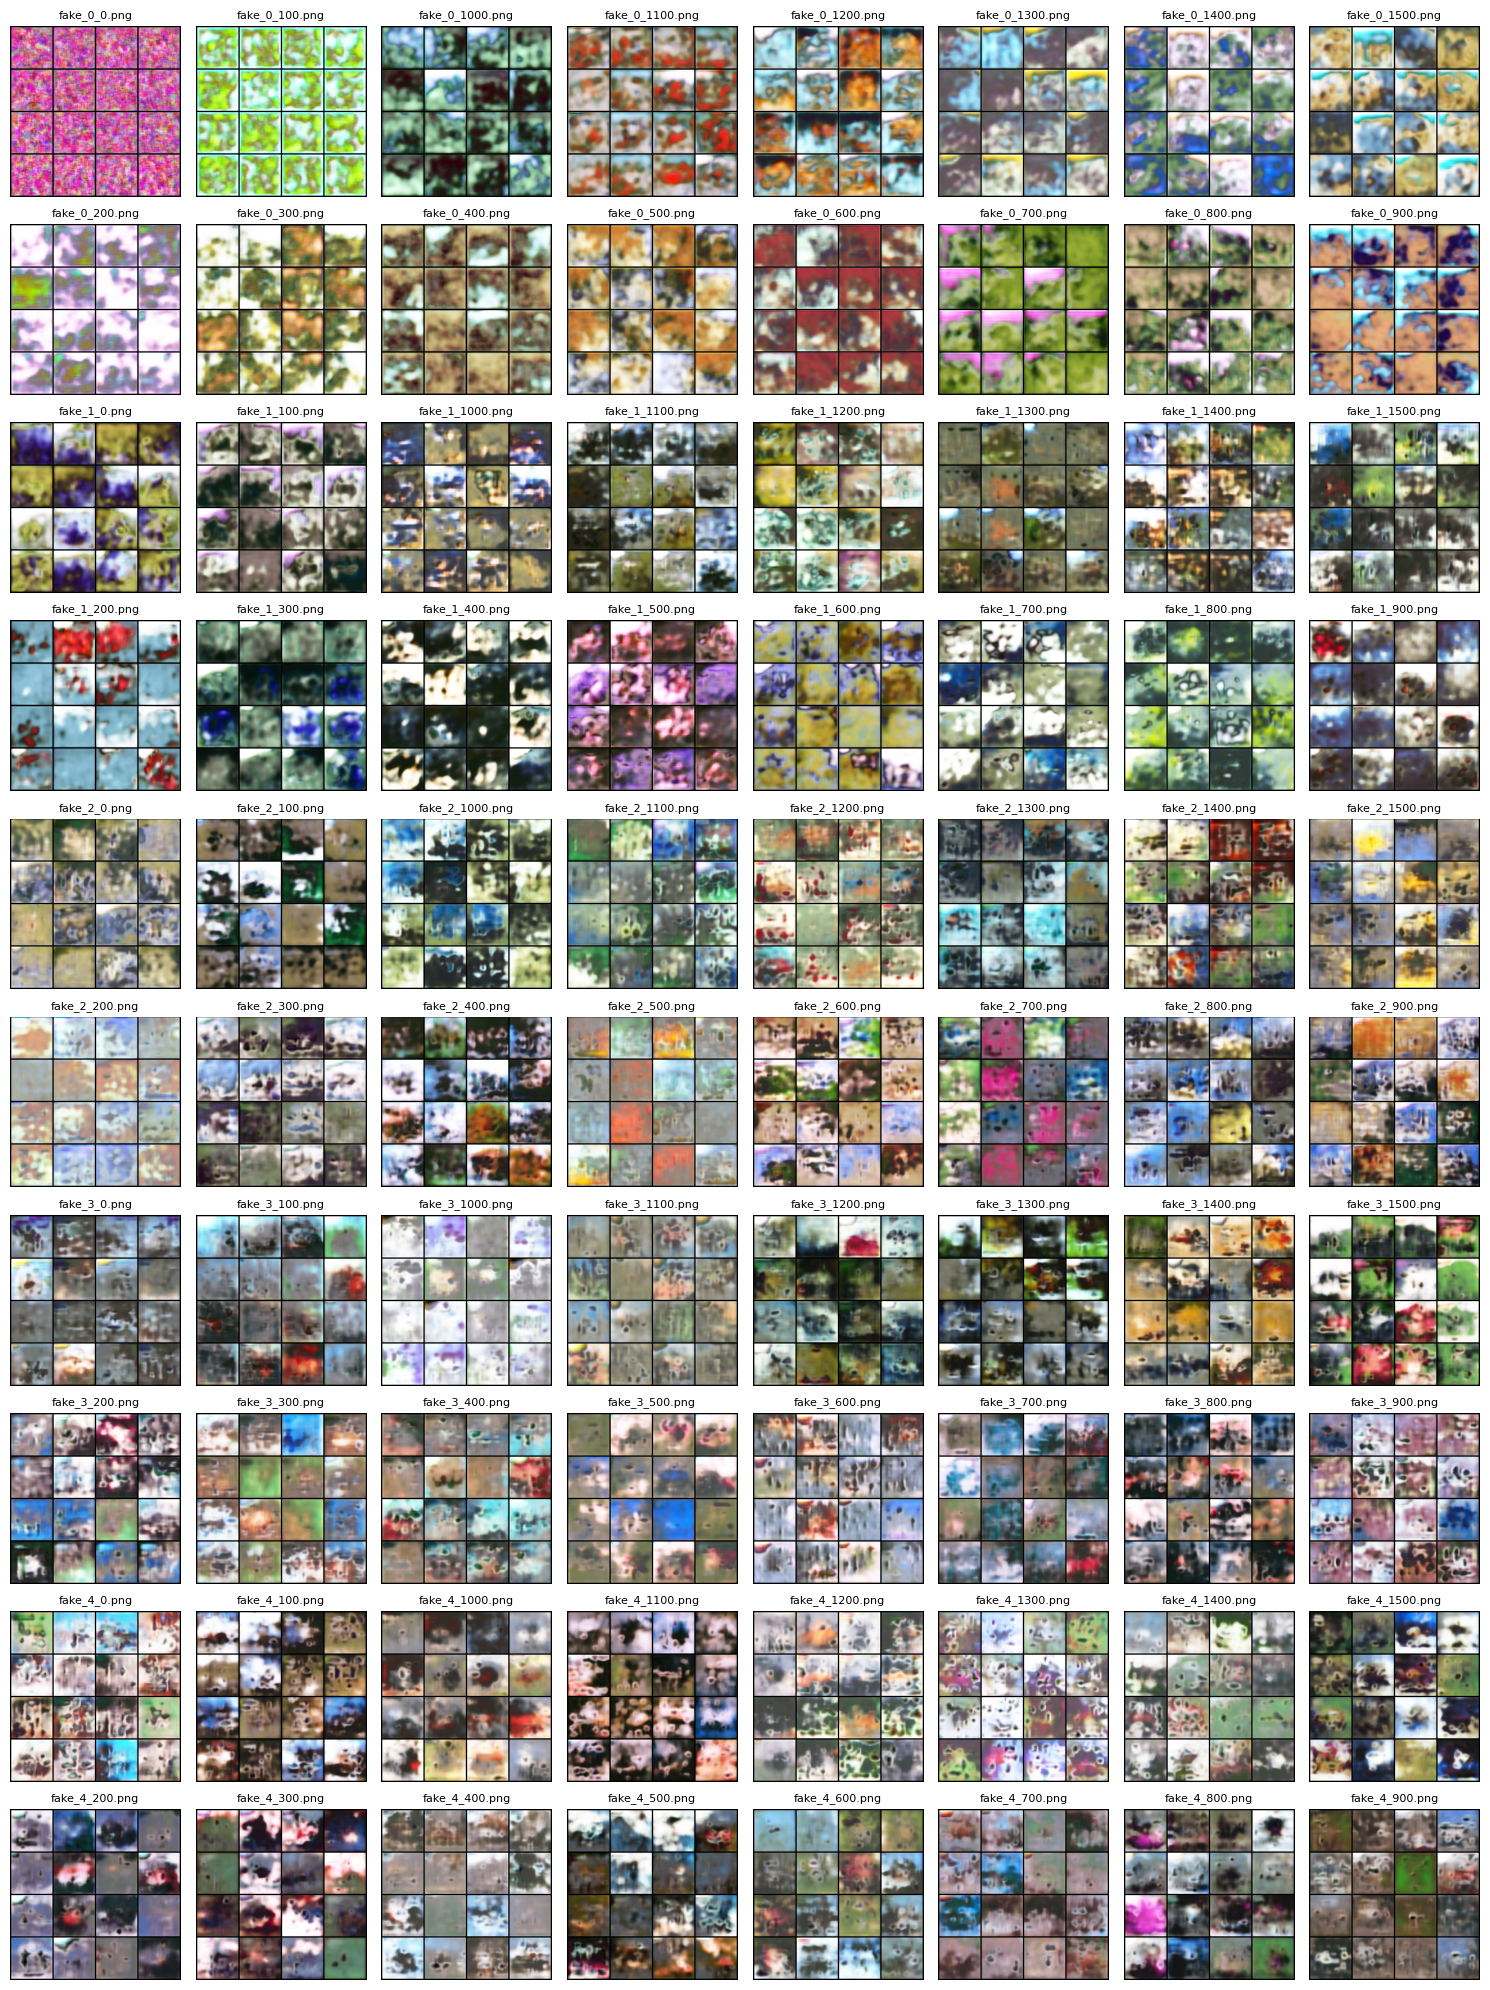

In [4]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List files in the gen_images folder
gen_images_dir = "/content/gen_images"
image_files = [f for f in os.listdir(gen_images_dir) if f.endswith('.png')]
image_files.sort() # Optional: sort by filename

print(f"Found {len(image_files)} generated images.")

# Display all images
num_images_to_display = len(image_files) # Display all images

if num_images_to_display > 0:
    # Determine grid size for displaying images
    cols = 8  # Number of columns in the grid
    rows = (num_images_to_display + cols - 1) // cols # Calculate number of rows

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 2))

    # Flatten the axes array for easier iteration
    axes = axes.flatten()

    for i in range(num_images_to_display):
        img_path = os.path.join(gen_images_dir, image_files[i])
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(image_files[i], fontsize=8)
        axes[i].axis('off') # Hide axes

    # Hide any unused subplots
    for j in range(num_images_to_display, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images found to display.")